## Polytope On-Demand Extremes-DT example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

In [ ]:
import earthkit.data
import earthkit.plots

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

## Data request

As for the global Extremes-DT output data is requested using the MARS language. The big difference here is that we have a new domain for every run which is done through the `georef` key, see below.

In [ ]:
request = {
    'class': 'd1',
    'dataset': 'on-demand-extremes-dt',
    'expver': '0099',
    'stream': 'oper',
    'date': '20250616',
    'time': 0,
    'type': 'fc',
    'levtype': 'sfc',
    'georef': 'u4usq2',
    'step': 12,
    'param': 167
}

In [ ]:
data_file = "../data/on-demands-extreme-dt-example.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    # data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

## Data inspection

We can list the data using the `ls` method. Here we see e.g. that we run the model in the `lambert_lam` projection.

In [ ]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,2t,heightAboveGround,2,20250616,0,12,fc,None,lambert_lam


## Plotting

Finally we create plot of the data retrieved using earthkit-plots.

/opt/homebrew/Caskroom/miniforge/base/envs/earthkit_0_13_2/lib/python3.12/site-packages/earthkit/plots/components/subplots.py:1392: UserWarning: block is deprecated and will be removed in a future release. Please use grid_cells instead.
  warnings.warn(


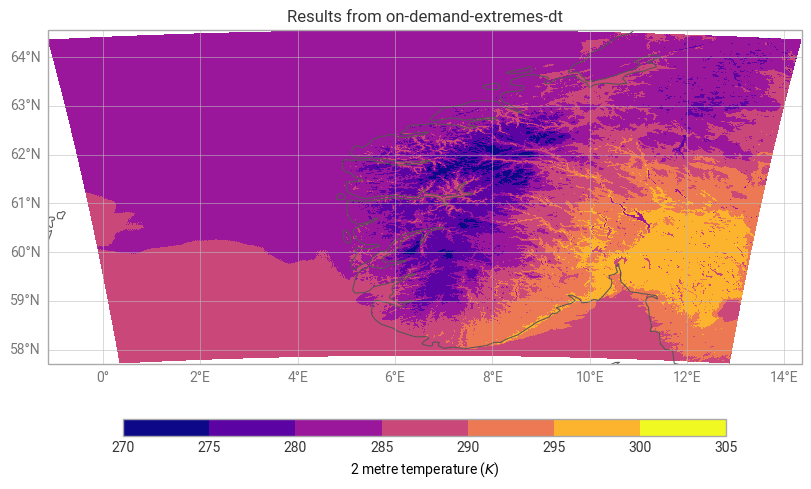

In [ ]:
chart = earthkit.plots.Map()
chart.block(data)
chart.title(f"Results from on-demand-extremes-dt")
chart.coastlines()
chart.gridlines()
chart.legend()
chart.show()